# Multivariate Analysis

## 1. load cleaned Sustainable living Quality index dataset.

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [67]:
slqi_dataset = pd.read_csv("../Dataset/final_SLQI_dataset.csv")
slqi_dataset.head()

,Country,Country Code,gdp_per_capita,inflation,unemployment_rate,life_expectancy,secondary_enrollment,electricity_access,drinking_water_access,sanitation_access,government_effectiveness,political_stability,rule_of_law,forest_area,pm25_exposure,renewable_energy
0,Afghanistan,AFG,413.757895,-6.601186,13.6870,66.289,59.613602,85.3,80.832437,54.495799,-1.933997,-2.205211,-1.935489,1.852782,46.087094,20.0
1,Albania,ALB,11377.775743,2.215874,10.6890,79.776,108.355392,100.0,95.119427,99.299715,0.312344,0.020467,-0.118502,28.791971,15.707004,41.9
2,Algeria,DZA,5752.990767,4.046115,11.6550,76.475,105.164132,100.0,92.420029,85.906486,-0.251191,-0.693588,-0.696777,0.830314,25.552656,0.1
3,American Samoa,ASM,18017.458938,3.117464,5.1895,72.992,92.659564,100.0,100.000000,62.119698,0.767382,1.253029,1.086581,85.200000,6.715147,0.4
4,Andorra,AND,49303.649167,3.117464,5.1895,84.188,101.923820,100.0,100.000000,100.000000,1.159037,1.543796,1.409905,34.042553,9.080281,18.7


## 2. Check basic information

In [68]:
slqi_dataset.shape
print("Dataset information:")
slqi_dataset.info()


Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Country                   206 non-null    str    
 1   Country Code              206 non-null    str    
 2   gdp_per_capita            206 non-null    float64
 3   inflation                 206 non-null    float64
 4   unemployment_rate         206 non-null    float64
 5   life_expectancy           206 non-null    float64
 6   secondary_enrollment      206 non-null    float64
 7   electricity_access        206 non-null    float64
 8   drinking_water_access     206 non-null    float64
 9   sanitation_access         206 non-null    float64
 10  government_effectiveness  206 non-null    float64
 11  political_stability       206 non-null    float64
 12  rule_of_law               206 non-null    float64
 13  forest_area               206 non-null    float64
 14  

In [69]:
print("\nMissing values:")
slqi_dataset.isna().sum()


Missing values:


Country                     0
Country Code                0
gdp_per_capita              0
inflation                   0
unemployment_rate           0
life_expectancy             0
secondary_enrollment        0
electricity_access          0
drinking_water_access       0
sanitation_access           0
government_effectiveness    0
political_stability         0
rule_of_law                 0
forest_area                 0
pm25_exposure               0
renewable_energy            0
dtype: int64

## 3. Select numerical indicators

In [70]:
indicator_cols = [
    "gdp_per_capita",
    "inflation",
    "unemployment_rate",
    "life_expectancy",
    "secondary_enrollment",
    "electricity_access",
    "drinking_water_access",
    "sanitation_access",
    "government_effectiveness",
    "political_stability",
    "rule_of_law",
    "forest_area",
    "pm25_exposure",
    "renewable_energy"
]

In [71]:
slqi_dataset[indicator_cols].describe()

,gdp_per_capita,inflation,unemployment_rate,life_expectancy,secondary_enrollment,electricity_access,drinking_water_access,sanitation_access,government_effectiveness,political_stability,rule_of_law,forest_area,pm25_exposure,renewable_energy
count,206.000000,206.000000,206.000000,206.000000,206.000000,206.000000,206.000000,206.000000,206.000000,206.000000,206.000000,206.000000,206.000000,206.000000
mean,21921.118678,7.937567,6.729267,73.717081,89.381236,87.665534,90.874102,81.253817,0.049222,-0.024762,-0.046080,32.470867,23.481144,30.031068
std,34372.211703,21.449114,5.370782,7.151911,24.272111,22.778118,13.582216,25.154985,0.966541,0.997872,1.013672,23.977237,14.754352,27.121666
min,219.424831,-12.296984,0.130000,54.635000,3.347850,5.400000,35.681361,10.357719,-2.172846,-2.750564,-2.205450,0.000000,4.895181,0.000000
25%,2757.805057,2.075134,3.410250,68.493000,84.528188,87.100000,88.182551,71.941009,-0.680011,-0.616041,-0.866880,11.536493,12.496784,8.825000
50%,8074.625991,3.117464,5.189500,74.173671,92.659564,100.000000,97.096571,92.991282,0.010027,0.015964,-0.144347,32.433058,20.028714,21.150000
75%,29272.479658,4.675934,8.373250,78.968817,101.836309,100.000000,99.760217,98.972923,0.704820,0.787683,0.718952,49.725946,29.434042,47.400000
max,288001.433369,219.883929,34.643000,86.497000,158.546616,100.000000,100.000000,100.000000,2.279627,1.582354,2.021270,94.447584,85.122346,96.300000


## 4. Histograms of selected indicators

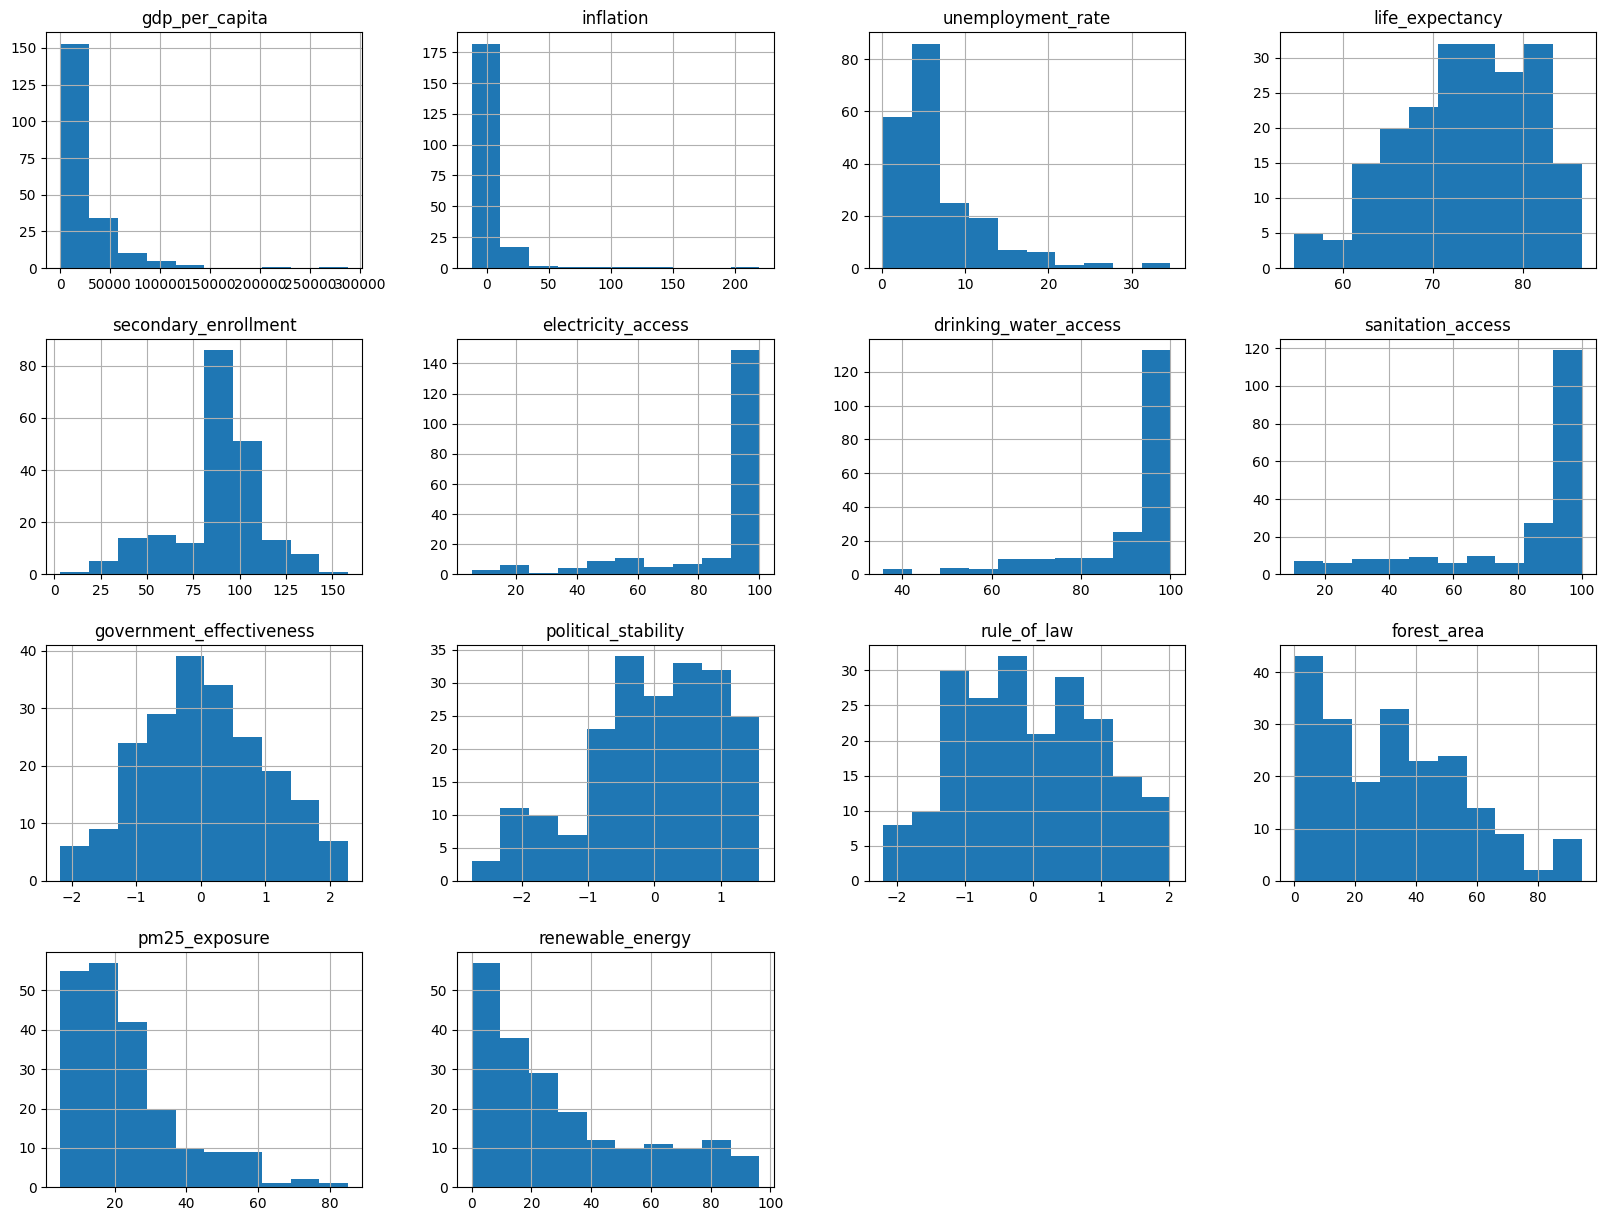

In [72]:
slqi_dataset.hist(figsize=(20, 15)) 
plt.show()

I used histograms to examine the distribution of the selected indicators. The results show that several variables are not normally distributed. 
- GDP per capita and inflation are strongly right-skewed, meaning that most countries have relatively low values while a small number of countries have very high values. 
- Infrastructure indicators such as electricity access, drinking water access, and sanitation access are mostly concentrated at higher values, suggesting that many countries have relatively strong access to basic services. 
- Life expectancy appears more evenly distributed, with most countries falling between around 70 and 80 years. 

## 5. Correlation Matrix

- A value close to `1` means a strong positive relationship.
- A value close to `-1` means a strong negative relationship.
- A value close to `0` means a weak or no linear relationship.

In [73]:
# correlation matrix for the indicators
correlation_matrix = slqi_dataset[indicator_cols].corr()
correlation_matrix

,gdp_per_capita,inflation,unemployment_rate,life_expectancy,secondary_enrollment,electricity_access,drinking_water_access,sanitation_access,government_effectiveness,political_stability,rule_of_law,forest_area,pm25_exposure,renewable_energy
gdp_per_capita,1.000000,-0.118262,-0.145076,0.598001,0.449909,0.311035,0.356098,0.371692,0.675757,0.450677,0.612707,-0.070351,-0.327148,-0.218307
inflation,-0.118262,1.000000,0.071863,-0.170809,0.002798,-0.178113,-0.209941,-0.158958,-0.224612,-0.230758,-0.224963,-0.117152,0.080804,0.098381
unemployment_rate,-0.145076,0.071863,1.000000,-0.145402,0.064060,-0.028451,-0.000884,0.021423,-0.222189,-0.185499,-0.171280,-0.092022,-0.027503,-0.016114
life_expectancy,0.598001,-0.170809,-0.145402,1.000000,0.574500,0.721512,0.734911,0.784042,0.761482,0.534350,0.671874,0.009228,-0.456745,-0.539785
secondary_enrollment,0.449909,0.002798,0.064060,0.574500,1.000000,0.520646,0.487283,0.496893,0.538617,0.452968,0.540095,0.050649,-0.450754,-0.419954
electricity_access,0.311035,-0.178113,-0.028451,0.721512,0.520646,1.000000,0.872802,0.838274,0.566875,0.499920,0.505878,0.056009,-0.446821,-0.666559
drinking_water_access,0.356098,-0.209941,-0.000884,0.734911,0.487283,0.872802,1.000000,0.887531,0.581103,0.542997,0.530382,0.077962,-0.416608,-0.666934
sanitation_access,0.371692,-0.158958,0.021423,0.784042,0.496893,0.838274,0.887531,1.000000,0.575439,0.480879,0.488823,0.042646,-0.453565,-0.677503
government_effectiveness,0.675757,-0.224612,-0.222189,0.761482,0.538617,0.566875,0.581103,0.575439,1.000000,0.691773,0.901283,0.061936,-0.438648,-0.384267
political_stability,0.450677,-0.230758,-0.185499,0.534350,0.452968,0.499920,0.542997,0.480879,0.691773,1.000000,0.804323,0.308178,-0.504680,-0.393762


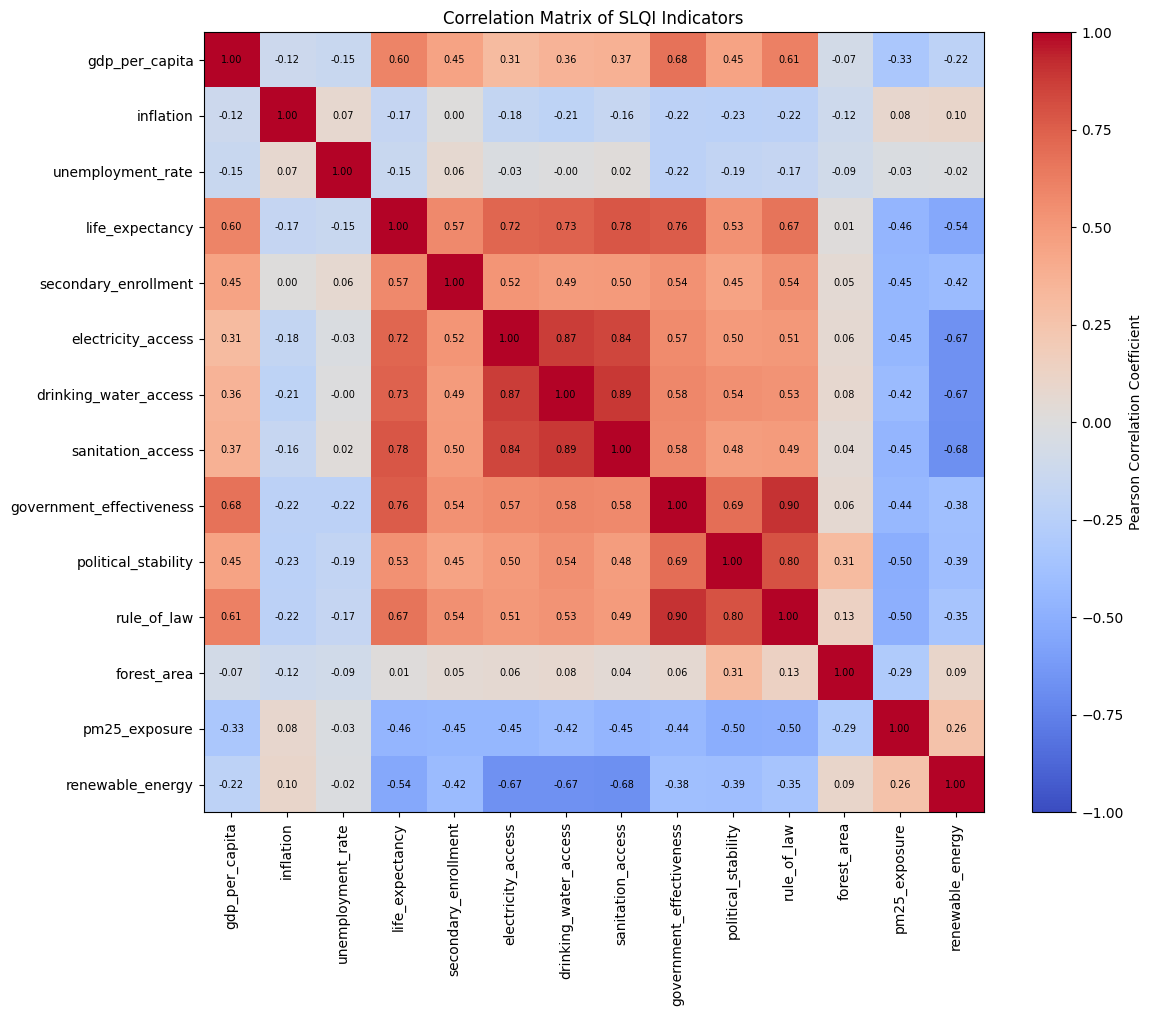

In [74]:
# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Pearson Correlation Coefficient")

plt.xticks(range(len(indicator_cols)), indicator_cols, rotation=90)
plt.yticks(range(len(indicator_cols)), indicator_cols)

# Add correlation values to the heatmap
for i in range(len(indicator_cols)):
    for j in range(len(indicator_cols)):
        value = corr_matrix.iloc[i, j]
        plt.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=7)

plt.title("Correlation Matrix of SLQI Indicators")
plt.tight_layout()
plt.show()

## 6. Identify strongest positive and negative relationships

In [78]:
# Convert the correlation matrix into pairs
correlation_pairs = correlation_matrix.unstack().reset_index()

# Rename columns
correlation_pairs.columns = ["Variable 1", "Variable 2", "Correlation"]

# Remove self-correlations where Variable 1 is the same as Variable 2
correlation_pairs = correlation_pairs[
    correlation_pairs["Variable 1"] != correlation_pairs["Variable 2"]
]

# Remove duplicated pairs
correlation_pairs["Pair"] = correlation_pairs.apply(
    lambda row: tuple(sorted([row["Variable 1"], row["Variable 2"]])),
    axis=1
)

correlation_pairs = correlation_pairs.drop_duplicates(subset="Pair")

# Drop the helper column
correlation_pairs = correlation_pairs.drop(columns="Pair")

# Add absolute correlation for sorting
correlation_pairs["Absolute Correlation"] = correlation_pairs["Correlation"].abs()

# Sort by strongest relationship
correlation_pairs = correlation_pairs.sort_values(
    by="Absolute Correlation",
    ascending=False
)

correlation_pairs.head(20)

,Variable 1,Variable 2,Correlation,Absolute Correlation
122,government_effectiveness,rule_of_law,0.901283,0.901283
91,drinking_water_access,sanitation_access,0.887531,0.887531
76,electricity_access,drinking_water_access,0.872802,0.872802
77,electricity_access,sanitation_access,0.838274,0.838274
136,political_stability,rule_of_law,0.804323,0.804323
49,life_expectancy,sanitation_access,0.784042,0.784042
50,life_expectancy,government_effectiveness,0.761482,0.761482
48,life_expectancy,drinking_water_access,0.734911,0.734911
47,life_expectancy,electricity_access,0.721512,0.721512
121,government_effectiveness,political_stability,0.691773,0.691773


In [81]:
# Strongest positive relationships
positive_correlations = correlation_pairs[
    correlation_pairs["Correlation"] > 0
].sort_values(
    by="Correlation",
    ascending=False
)

positive_correlations.head(20)

,Variable 1,Variable 2,Correlation,Absolute Correlation
122,government_effectiveness,rule_of_law,0.901283,0.901283
91,drinking_water_access,sanitation_access,0.887531,0.887531
76,electricity_access,drinking_water_access,0.872802,0.872802
77,electricity_access,sanitation_access,0.838274,0.838274
136,political_stability,rule_of_law,0.804323,0.804323
49,life_expectancy,sanitation_access,0.784042,0.784042
50,life_expectancy,government_effectiveness,0.761482,0.761482
48,life_expectancy,drinking_water_access,0.734911,0.734911
47,life_expectancy,electricity_access,0.721512,0.721512
121,government_effectiveness,political_stability,0.691773,0.691773


In [84]:
# Strongest negative relationships
negative_correlations = correlation_pairs[
    correlation_pairs["Correlation"] < 0
].sort_values(
    by="Correlation",
    ascending=True
)

negative_correlations.head(10)

,Variable 1,Variable 2,Correlation,Absolute Correlation
111,sanitation_access,renewable_energy,-0.677503,0.677503
97,drinking_water_access,renewable_energy,-0.666934,0.666934
83,electricity_access,renewable_energy,-0.666559,0.666559
55,life_expectancy,renewable_energy,-0.539785,0.539785
138,political_stability,pm25_exposure,-0.504680,0.504680
152,rule_of_law,pm25_exposure,-0.499473,0.499473
54,life_expectancy,pm25_exposure,-0.456745,0.456745
110,sanitation_access,pm25_exposure,-0.453565,0.453565
68,secondary_enrollment,pm25_exposure,-0.450754,0.450754
82,electricity_access,pm25_exposure,-0.446821,0.446821


## 7. Scatter plots with trend lines

In [85]:
def plot_scatter_with_trendline(x_col, y_col):
    # Select only the two columns needed
    plot_data = slqi_dataset[[x_col, y_col]].copy()
    
    # Make sure the columns are numeric
    plot_data[x_col] = pd.to_numeric(plot_data[x_col], errors="coerce")
    plot_data[y_col] = pd.to_numeric(plot_data[y_col], errors="coerce")
    
    # Remove missing values
    plot_data = plot_data.dropna()
    
    # Create scatter plot
    plt.figure(figsize=(8, 6))
    plt.scatter(plot_data[x_col], plot_data[y_col])
    
    # Create trend line
    m, b = np.polyfit(plot_data[x_col], plot_data[y_col], 1)
    x_values = np.linspace(plot_data[x_col].min(), plot_data[x_col].max(), 100)
    y_values = m * x_values + b
    
    plt.plot(x_values, y_values)
    
    # Add labels and title
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"{x_col} vs {y_col}")
    
    plt.tight_layout()
    plt.show()

After identifying the strongest positive and negative correlations, i used scatter plots to visualise selected relationships in more detail. A trend line was added to each plot to show the general direction of the relationship between the two indicators.

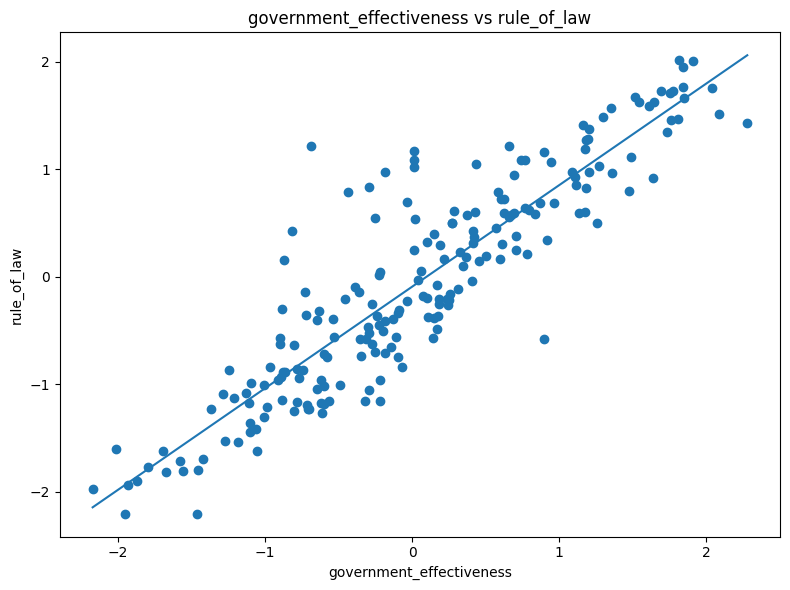

In [ ]:
plot_scatter_with_trendline("government_effectiveness", "rule_of_law")

- Government effectiveness and rule of law show a strong positive relationship. This means that countries with more effective governments also tend to have stronger rule of law.

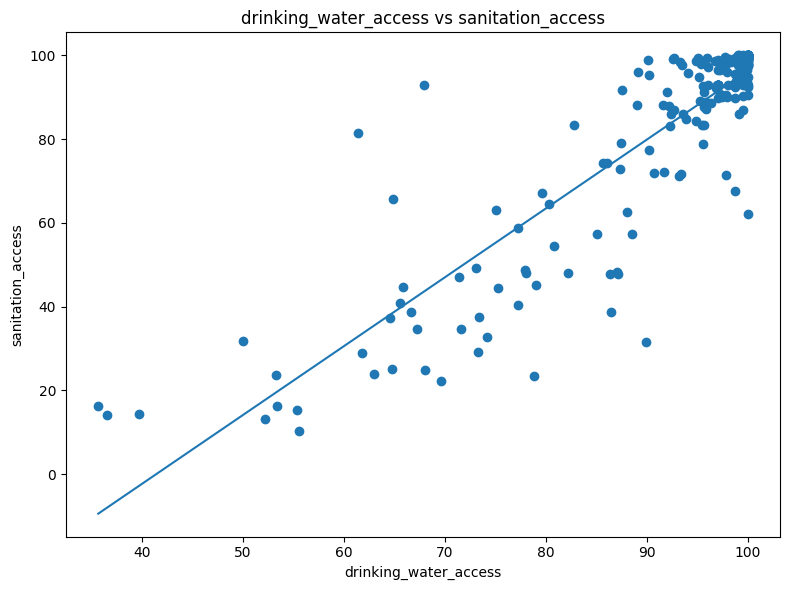

In [ ]:
plot_scatter_with_trendline("drinking_water_access","sanitation_access")

- Drinking water access and sanitation access are strongly positively correlated. Countries with better access to clean drinking water also tend to have better sanitation services.

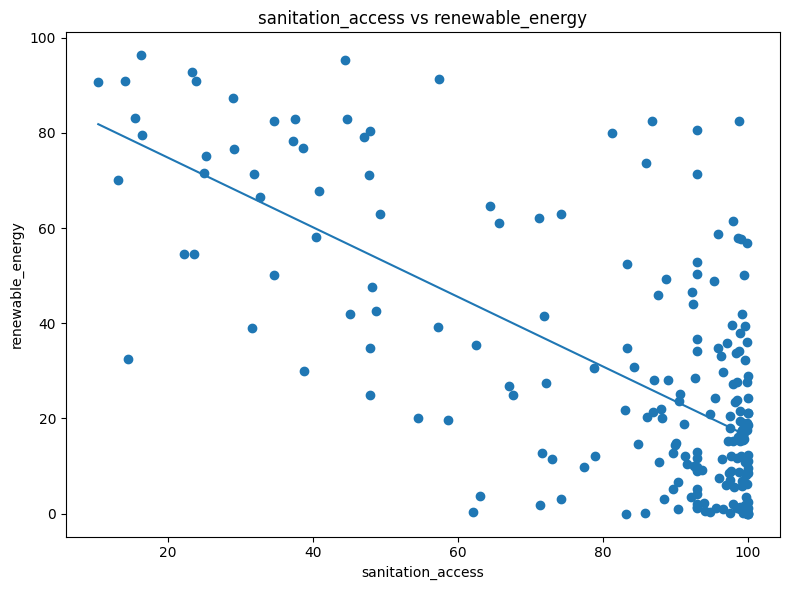

In [ ]:
plot_scatter_with_trendline("sanitation_access", "renewable_energy")

- Sanitation access and renewable energy show a moderate negative relationship. This does not mean renewable energy has a negative effect on living quality. It may reflect that some countries with high renewable energy shares still have weaker infrastructure, possibly because they rely more on traditional biomass or less industrialised energy systems.

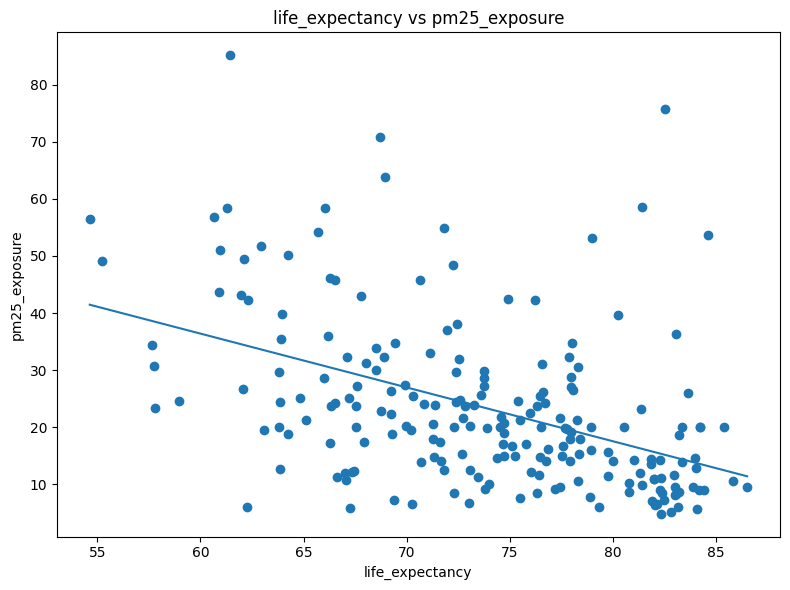

In [ ]:
plot_scatter_with_trendline( "life_expectancy", "pm25_exposure")

- Life expectancy and PM2.5 exposure show a negative relationship. This suggests that countries with higher air pollution exposure tend to have lower life expectancy.

## 8. Principal Component Analysis (PCA)

In [91]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [92]:
# Select only the indicator columns for PCA
pca_data = slqi_dataset[indicator_cols].copy()

# Make sure all selected columns are numeric
pca_data = pca_data.apply(pd.to_numeric, errors="coerce")

# Remove rows with missing values
pca_data = pca_data.dropna()

print("PCA data shape:", pca_data.shape)
pca_data.head()

PCA data shape: (206, 14)


,gdp_per_capita,inflation,unemployment_rate,life_expectancy,secondary_enrollment,electricity_access,drinking_water_access,sanitation_access,government_effectiveness,political_stability,rule_of_law,forest_area,pm25_exposure,renewable_energy
0,413.757895,-6.601186,13.6870,66.289,59.613602,85.3,80.832437,54.495799,-1.933997,-2.205211,-1.935489,1.852782,46.087094,20.0
1,11377.775743,2.215874,10.6890,79.776,108.355392,100.0,95.119427,99.299715,0.312344,0.020467,-0.118502,28.791971,15.707004,41.9
2,5752.990767,4.046115,11.6550,76.475,105.164132,100.0,92.420029,85.906486,-0.251191,-0.693588,-0.696777,0.830314,25.552656,0.1
3,18017.458938,3.117464,5.1895,72.992,92.659564,100.0,100.000000,62.119698,0.767382,1.253029,1.086581,85.200000,6.715147,0.4
4,49303.649167,3.117464,5.1895,84.188,101.923820,100.0,100.000000,100.000000,1.159037,1.543796,1.409905,34.042553,9.080281,18.7


In [93]:
# Standardise the indicator data
scaler = StandardScaler()
scaled_pca_data = scaler.fit_transform(pca_data)

scaled_pca_data

array([[-0.62724372, -0.67947655,  1.29863438, ..., -1.28007546,
         1.53588711, -0.3707554 ],
       [-0.30748755, -0.26740646,  0.73906909, ..., -0.15380663,
        -0.52818848,  0.43868417],
       [-0.47152958, -0.18186915,  0.91936932, ..., -1.32282261,
         0.14074207, -1.10627355],
       ...,
       [-0.40382108, -0.22527015,  1.91139383, ..., -1.31406314,
         0.77122113, -0.97321499],
       [-0.60468959,  0.32939491, -0.15515282, ...,  1.13102357,
         0.05621822,  1.95776939],
       [-0.56648182,  4.52248691,  0.50501477, ...,  0.51280536,
        -0.27088123,  1.93559297]], shape=(206, 14))

In [94]:
# Apply PCA
pca = PCA()
pca_result = pca.fit_transform(scaled_pca_data)

# Explained variance ratio
explained_variance = pca.explained_variance_ratio_

explained_variance

array([0.47285362, 0.1148433 , 0.08745419, 0.07748   , 0.06303352,
       0.03834699, 0.03469719, 0.03404315, 0.0263026 , 0.01771158,
       0.01270126, 0.00949708, 0.00659074, 0.00444477])

In [105]:
# Create a table for explained variance
pca_summary = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(len(explained_variance))],
    "Explained Variance Ratio": explained_variance,
    "Explained Variance Percentage": explained_variance * 100,
})

pca_summary

,Principal Component,Explained Variance Ratio,Explained Variance Percentage
0,PC1,0.472854,47.285362
1,PC2,0.114843,11.484330
2,PC3,0.087454,8.745419
3,PC4,0.077480,7.748000
4,PC5,0.063034,6.303352
5,PC6,0.038347,3.834699
6,PC7,0.034697,3.469719
7,PC8,0.034043,3.404315
8,PC9,0.026303,2.630260
9,PC10,0.017712,1.771158


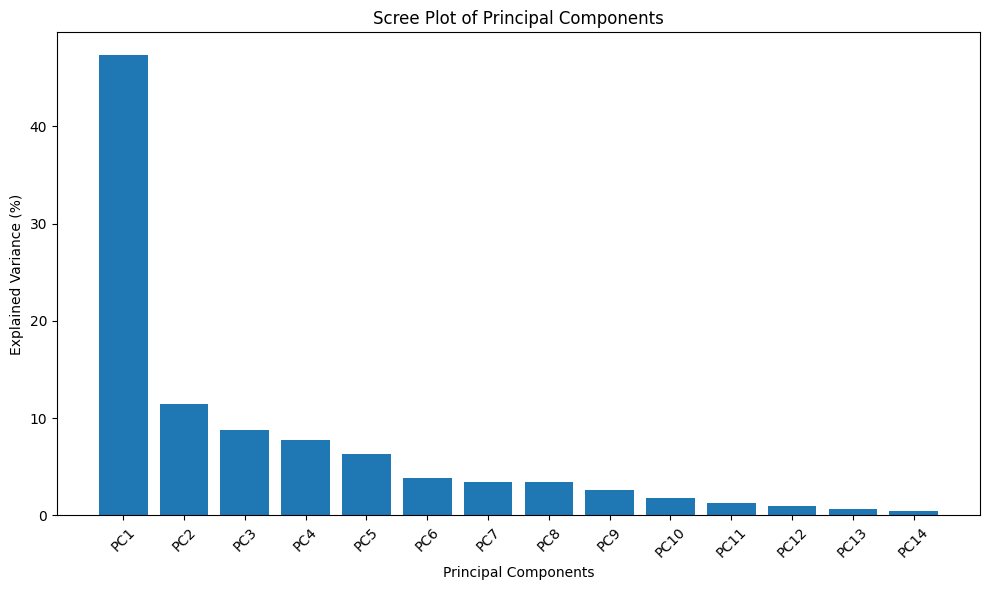

In [104]:
plt.figure(figsize=(10, 6))

plt.bar(
    pca_summary["Principal Component"],
    pca_summary["Explained Variance Percentage"]
)

plt.xlabel("Principal Components")
plt.ylabel("Explained Variance (%)")
plt.title("Scree Plot of Principal Components")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Most of the variation in the dataset is captured by the first few components, especially PC1.

In [97]:
# Find the number of components needed to explain at least 80% of variance
components_80 = np.argmax(pca_summary["Cumulative Variance Percentage"] >= 80) + 1

print(f"Number of components needed to explain at least 80% of the variance: {components_80}")

Number of components needed to explain at least 80% of the variance: 5


In [98]:
loading_scores = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(indicator_cols))],
    index=indicator_cols
)

loading_scores

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14
gdp_per_capita,0.242689,-0.248452,-0.420032,0.139730,-0.175662,-0.295472,0.284146,-0.039892,-0.592581,0.326336,0.137877,0.033269,-0.026991,0.066624
inflation,-0.094795,0.161005,-0.209515,0.612453,0.660285,0.140988,0.141611,-0.262409,0.014236,0.005660,0.026580,0.005803,0.017694,-0.006396
unemployment_rate,-0.045239,0.389866,0.184489,0.479148,-0.659844,0.186185,0.217819,-0.217006,-0.022914,-0.080019,-0.003914,0.090951,-0.009917,-0.049286
life_expectancy,0.342208,0.047306,-0.147047,-0.042878,0.047805,-0.268701,0.202661,-0.022684,0.089842,-0.430393,-0.517018,0.481215,0.219818,-0.024870
secondary_enrollment,0.265970,0.044783,-0.074146,0.391876,-0.032233,0.046622,-0.030075,0.837255,0.190829,0.112294,-0.061735,-0.099426,-0.006400,-0.017711
electricity_access,0.323142,0.280974,0.122370,-0.127894,0.113058,-0.083322,0.035554,-0.018309,0.231067,0.243573,0.521226,0.552775,-0.260571,0.078257
drinking_water_access,0.329893,0.268313,0.126682,-0.154069,0.060047,-0.037533,0.172255,-0.129637,0.117072,0.332678,0.054314,-0.328095,0.683721,-0.159528
sanitation_access,0.327177,0.301655,0.088550,-0.097775,0.076387,-0.183364,0.152444,-0.139491,0.040055,0.026316,-0.314117,-0.476201,-0.564081,0.237661
government_effectiveness,0.330872,-0.244627,-0.208769,-0.003191,-0.066409,0.110762,0.106613,-0.128702,0.205002,-0.374756,0.318210,-0.231432,-0.195469,-0.605791
political_stability,0.295621,-0.289662,0.148387,0.019416,0.011815,0.513889,-0.153827,-0.170201,-0.040694,0.443276,-0.424224,0.210264,-0.142962,-0.216083


In [106]:
# Main contributors to PC1
pc1_loadings = loading_scores["PC1"].sort_values(key=abs, ascending=False)

print("Main contributors to PC1:")
display(pc1_loadings.head(10))

# Main contributors to PC2
pc2_loadings = loading_scores["PC2"].sort_values(key=abs, ascending=False)

print("Main contributors to PC2:")
display(pc2_loadings.head(10))

# Main contributors to PC3
pc3_loadings = loading_scores["PC3"].sort_values(key=abs, ascending=False)

print("Main contributors to PC3:")
display(pc3_loadings.head(10))

# Main contributors to PC4
pc4_loadings = loading_scores["PC4"].sort_values(key=abs, ascending=False)

print("Main contributors to PC4:")
display(pc4_loadings.head(10))

# Main contributors to PC5
pc5_loadings = loading_scores["PC5"].sort_values(key=abs, ascending=False)

print("Main contributors to PC5:")
display(pc5_loadings.head(10))


Main contributors to PC1:


life_expectancy             0.342208
government_effectiveness    0.330872
drinking_water_access       0.329893
sanitation_access           0.327177
electricity_access          0.323142
rule_of_law                 0.320051
political_stability         0.295621
secondary_enrollment        0.265970
renewable_energy           -0.254042
gdp_per_capita              0.242689
Name: PC1, dtype: float64

Main contributors to PC2:


unemployment_rate           0.389866
renewable_energy           -0.385121
forest_area                -0.331966
rule_of_law                -0.312687
sanitation_access           0.301655
political_stability        -0.289662
electricity_access          0.280974
drinking_water_access       0.268313
gdp_per_capita             -0.248452
government_effectiveness   -0.244627
Name: PC2, dtype: float64

Main contributors to PC3:


forest_area                 0.711574
gdp_per_capita             -0.420032
pm25_exposure              -0.309721
inflation                  -0.209515
government_effectiveness   -0.208769
unemployment_rate           0.184489
political_stability         0.148387
life_expectancy            -0.147047
drinking_water_access       0.126682
electricity_access          0.122370
Name: PC3, dtype: float64

Main contributors to PC4:


inflation                0.612453
unemployment_rate        0.479148
secondary_enrollment     0.391876
pm25_exposure           -0.365514
renewable_energy         0.154947
drinking_water_access   -0.154069
gdp_per_capita           0.139730
electricity_access      -0.127894
sanitation_access       -0.097775
forest_area              0.081994
Name: PC4, dtype: float64

Main contributors to PC5:


inflation                   0.660285
unemployment_rate          -0.659844
forest_area                 0.194236
gdp_per_capita             -0.175662
renewable_energy           -0.132998
electricity_access          0.113058
rule_of_law                -0.109849
sanitation_access           0.076387
government_effectiveness   -0.066409
drinking_water_access       0.060047
Name: PC5, dtype: float64

- The PCA results show that PC1 explains 47.28% of the total variance, making it the most important principal component. This suggests that many SLQI indicators share a common underlying pattern. Based on the loading scores, PC1 is mainly influenced by life expectancy, infrastructure access, governance indicators, secondary education, and GDP per capita. Therefore, PC1 can be interpreted as an overall development and living quality component.

- PC1 alone does not explain the full dataset structure. The first five principal components together explain about 81.57% of the total variance, meaning that five components are needed to retain most of the information from the original indicators. This supports the idea that sustainable living quality is multidimensional and should not be represented by only one indicator or one component.

## 9. Cluster Analysis

In [107]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [108]:
# Use the first 5 principal components for clustering
pca_for_clustering = pca_result[:, :components_80]

print("PCA data used for clustering shape:", pca_for_clustering.shape)

PCA data used for clustering shape: (206, 5)


In [125]:
num_clusters = 4
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)

clusters = kmeans.fit_predict(pca_for_clustering)

silhouette_avg = silhouette_score(pca_for_clustering, clusters)

print("Number of clusters:", num_clusters)
print("Silhouette score:", silhouette_avg)

Number of clusters: 4
Silhouette score: 0.2966518183021288


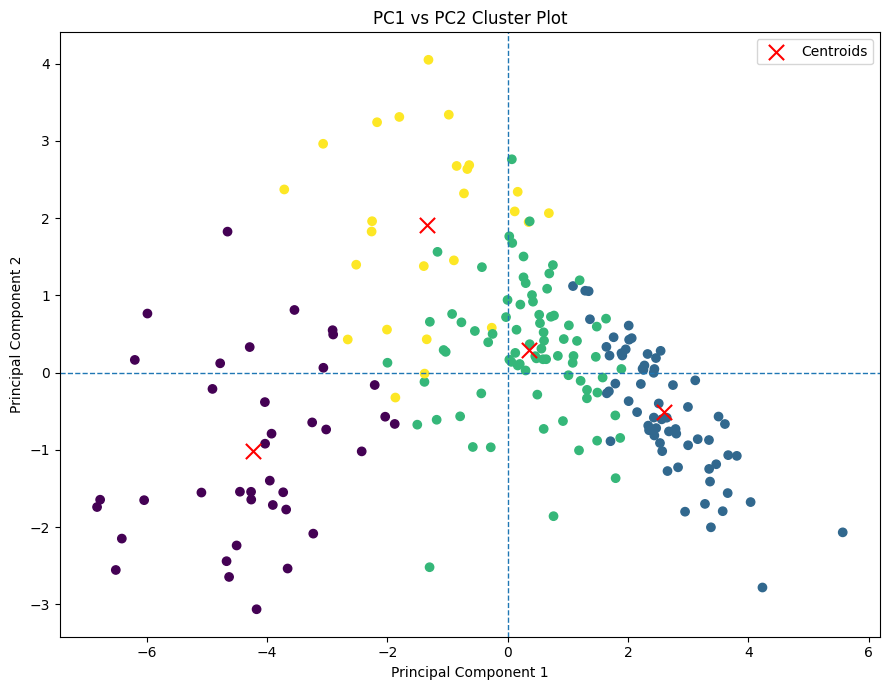

In [ ]:
plt.figure(figsize=(9, 7))
plt.scatter(pca_for_clustering[:, 0], pca_for_clustering[:, 1], c=clusters)
plt.scatter( kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker="x", s=120,c="red",label="Centroids")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PC1 vs PC2 Cluster Plot")

plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)

plt.legend()
plt.tight_layout()
plt.show()

In [119]:
clustered_dataset = slqi_dataset.copy()

clustered_dataset["cluster"] = clusters

clustered_dataset.head(206)

,Country,Country Code,gdp_per_capita,inflation,unemployment_rate,life_expectancy,secondary_enrollment,electricity_access,drinking_water_access,sanitation_access,government_effectiveness,political_stability,rule_of_law,forest_area,pm25_exposure,renewable_energy,cluster
0,Afghanistan,AFG,413.757895,-6.601186,13.6870,66.289000,59.613602,85.3,80.832437,54.495799,-1.933997,-2.205211,-1.935489,1.852782,46.087094,20.0,3
1,Albania,ALB,11377.775743,2.215874,10.6890,79.776000,108.355392,100.0,95.119427,99.299715,0.312344,0.020467,-0.118502,28.791971,15.707004,41.9,2
2,Algeria,DZA,5752.990767,4.046115,11.6550,76.475000,105.164132,100.0,92.420029,85.906486,-0.251191,-0.693588,-0.696777,0.830314,25.552656,0.1,3
3,American Samoa,ASM,18017.458938,3.117464,5.1895,72.992000,92.659564,100.0,100.000000,62.119698,0.767382,1.253029,1.086581,85.200000,6.715147,0.4,2
4,Andorra,AND,49303.649167,3.117464,5.1895,84.188000,101.923820,100.0,100.000000,100.000000,1.159037,1.543796,1.409905,34.042553,9.080281,18.7,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201,Virgin Islands (U.S.),VIR,44320.909186,3.117464,11.4230,80.770732,92.659564,100.0,99.465680,99.258882,0.374791,0.971170,0.579312,58.171429,8.633428,5.9,1
202,West Bank and Gaza,PSE,2592.305912,53.669146,24.4200,69.213000,89.121098,100.0,98.771707,99.395017,-1.098591,-1.876352,-0.989397,1.682988,26.363626,15.4,3
203,"Yemen, Rep.",YEM,8074.625991,3.117464,16.9700,69.439000,92.659564,83.6,75.035762,63.082731,-1.872798,-2.750564,-1.901590,1.039832,34.832360,3.7,3
204,Zambia,ZMB,1187.109434,14.985626,5.8980,66.528000,56.788929,51.1,73.412038,37.476336,-0.533056,-0.100785,-0.561177,59.523784,24.308592,83.0,0


In [ ]:
clustered_dataset["cluster"].value_counts().sort_index()

cluster
0    38
1    64
2    79
3    25
Name: count, dtype: int64

In [132]:
cluster_profiles = clustered_dataset.groupby("cluster")[indicator_cols].mean()

cluster_profiles

,gdp_per_capita,inflation,unemployment_rate,life_expectancy,secondary_enrollment,electricity_access,drinking_water_access,sanitation_access,government_effectiveness,political_stability,rule_of_law,forest_area,pm25_exposure,renewable_energy
cluster,,,,,,,,,,,,,,
0,1678.643037,17.750056,5.303842,63.709921,61.915266,47.292105,67.730923,39.053369,-0.909635,-1.090827,-0.999261,28.355546,39.139986,70.578947
1,55941.534562,2.527696,5.196625,81.050180,107.189275,100.000000,99.317094,98.193239,1.149874,0.742038,1.065296,29.940329,16.129173,18.734375
2,9714.311479,7.326137,5.675354,73.521565,90.000157,97.059494,95.009588,88.221447,-0.141791,0.177211,-0.233904,42.394224,19.385394,21.308861
3,4170.927737,8.803971,16.149840,70.773060,83.585139,87.772000,91.369539,80.015863,-0.707383,-1.005587,-0.848842,13.846522,31.443324,24.880000


In [133]:
cluster_profiles.T

cluster,0,1,2,3
gdp_per_capita,1678.643037,55941.534562,9714.311479,4170.927737
inflation,17.750056,2.527696,7.326137,8.803971
unemployment_rate,5.303842,5.196625,5.675354,16.149840
life_expectancy,63.709921,81.050180,73.521565,70.773060
secondary_enrollment,61.915266,107.189275,90.000157,83.585139
electricity_access,47.292105,100.000000,97.059494,87.772000
drinking_water_access,67.730923,99.317094,95.009588,91.369539
sanitation_access,39.053369,98.193239,88.221447,80.015863
government_effectiveness,-0.909635,1.149874,-0.141791,-0.707383
political_stability,-1.090827,0.742038,0.177211,-1.005587


The cluster plot shows the K-Means clustering result using the PCA1 - 5. Each point represents one country, and the colour shows the cluster assigned to that country. The red crosses represent the centroids of the clusters.

Although the plot only displays PC1 and PC2, the clustering was carried out using PC1 to PC5, which together explain over 80% of the total variance. Four clusters were selected to group countries with similar sustainable living profiles.

In [135]:
clustered_dataset.to_csv("../Dataset/slqi_clustered_dataset.csv", index=False)